# End-to-end Comet Spectra Simulations

### Imports

In [ ]:
# basic
from copy import deepcopy
from pathlib import Path
from typing import Optional, Literal
import logging
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.io import fits
from astropy.table import Table
from scipy.ndimage import median_filter

# zs_scopesim_tools convenience routines
import zs_scopesim_tools.helpers
from zs_scopesim_tools.helpers import (disable_scopesim_top_level_catch, warning_prevent_sync_alt_ra_dec,
                                       ignore_warnings, set_scopesim_log_level, make_local_output_dir, configure_irdb_path, timed, list_effects, simulate, save_zshooter_readout, subtract_hduls)
# scopesim and scopesim source creation related
import scopesim as sim
import scopesim_templates as sim_tp
from scopesim.source.source import Source
import scopesim.source.source_templates as source_templates
from zs_scopesim_tools.sources import lamp_flat, transient, kilonova_spectra, empirical_spectrum
from zs_scopesim_tools.plots import PlotScene, plot_readout_overview
from synphot.units import convert_flux, FLAM

# DRP
from zsdrp.ZSHOOTER import ZSHOOTER
import zsdrp.pipe, zsdrp.steps


configure_irdb_path()  # REQUIRED the first time after installation, sets local IRDB directory path in ScopeSim
set_scopesim_log_level("warning")  # set ScopeSim log toggles
disable_scopesim_top_level_catch()
ignore_warnings()
logging.disable(logging.WARNING)

### Setup

Set up OUTPUT directory, remember to change it if running different simulations from same notebook to prevent accidental
overrides.

In [6]:
OUTDIR = make_local_output_dir(dirname="05_Comets/")

In [7]:
zs_config = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

##### Helper function to update observing parameters and run simulation in one-shot

Example usage:
```python
hdul, train = update_params_and_observe(
                        object_name = "object_name_identifier", # string name
                        imagetype = "SCIENCE", # one of BIAS, DOMEFLAT, ARCS, SCIENCE
                        source = Source, # scopesim Source object instance
                        exptimes = [300, 300, 300, 100, 100, 100], # list of 6 numbers, one per channel
                        ndit = 2, # Number of exposures to take at above exptime, same for all 6 channels
                        output_dir = "/path/to/output/directory",
                        disable_effects = ["name_of_effect_to_disable", "..."], # see list_effects()
                        disable_backgrounds = ["sky_lines"], # from "sky", "sky_lines", "sky_continuum"
                        airmass = 1.3,
                        seeing = 0.7,
                        brightness = "grey", # options: "bright", "grey", "dark"
                        vis_slit = 0.7, # options: 1.25, 0.70, 0.57, 0.50, 0.42, 0.37, 0.33
                        nir_slit = 0.7, # options: 1.25, 0.70, 0.57, 0.50, 0.42, 0.37, 0.33
                        pixel_scale = None, # uses instrument default
                        pupil_angle = None, # uses instrument default
                        ao_on = False, # AO effect ON/OFF
                        diffuse_emissivity_on = False
)
```
Returns a tuple of:
 - list of size `ndit`, each item of which is a list of 6 fits.HDUList (one per channel), the raw images from scopesim readout
  - The scopesim OpticalTrain object

In [8]:
@timed
def update_params_and_observe(object_name: str,
                              imagetype: str,
                              source: Source,
                              exptimes: Optional[list | float] = None,
                              ndit: int = 1,
                              output_dir: Optional[str | Path]=None,
                              *,
                              disable_effects: Optional[list[str]]=None,
                              disable_backgrounds: Optional[list[Literal["sky", "sky_continuum", "sky_lines"]]]=None,
                              airmass: Optional[float]=None,
                              seeing: Optional[float]=None,
                              brightness: Optional[Literal["bright", "grey", "dark"]]=None,
                              vis_slit: Optional[float]=None,
                              nir_slit: Optional[float]=None,
                              pixel_scale: Optional[float]=None,
                              pupil_angle: Optional[float]=None,
                              ao_on: bool=False,
                              diffuse_emissivity_on: bool=False,
                              params: Optional[dict]=None
                              ) -> tuple[list, sim.optics.OpticalTrain]:
    """
    :param object_name: Name of the Source object
    :param imagetype: IMAGETYPE keyword (BIAS, DOMEFLAT, ARCS, SKY, SCIENCE)
    :param source: Source instance
    :param exptimes: List of exposure times in channel order (blue, green, red, yj, h, k) in seconds, or single value.
                If None, it is set to 0.0.
    :param ndit: number of exposures
    :param output_dir: Directory to save observed data in, FITS files are saved with {object_name}_{CHANNEL}.fits names
                        where CHANNEL is in [BLUE, GREEN, RED, YJ, H, K] (upper case)
    :param disable_effects: List of effect names to disable
    :param disable_backgrounds: List of background names to disable, options are "sky", "sky_continuum", or "sky_lines".
    :param airmass: Airmass
    :param seeing: Seeing (natural)
    :param brightness: Brightness of sky ("bright", "grey", or "dark")
    :param vis_slit: Slit width for Visible channel
    :param nir_slit: Slit width for NIR channel
    :param pixel_scale: Instrument pixel scale
    :param pupil_angle: Instrument pupil angle
    :param ao_on: True for AO correction on, defaults to False
    :param diffuse_emissivity_on: True for diffuse emissivity effect on, defaults to False
    :param params: Dict of any other UserCommands alias keys and values to set

    :return: tuple(HDUList, OpticalTrain)
    """
    if imagetype not in ["BIAS", "DOMEFLAT", "ARCS", "SKY", "SCIENCE"]:
        raise ValueError(f"Imagetype {imagetype} is incorrect! Choose from BIAS, DOMEFLAT, ARCS, SCIENCE.")
    # load ZShooter_v2 irdb model config
    config = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
    # update with passed params
    config["!OBS.airmass"] = airmass if airmass else config["!OBS.airmass"]
    config["!OBS.seeing"] = seeing if seeing else config["!OBS.seeing"]
    config["!OBS.brightness"] = brightness if brightness else config["!OBS.brightness"]
    config["!OBS.pupil_angle"] = pupil_angle if pupil_angle else config["!OBS.pupil_angle"]
    config["!INST.vis_curr_slit"] = vis_slit if vis_slit else config["!INST.vis_curr_slit"]
    config["!INST.nir_curr_slit"] = nir_slit if nir_slit else config["!INST.nir_curr_slit"]
    config["!INST.pixel_scale"] = pixel_scale if pixel_scale else config["!INST.pixel_scale"]
    config["!INST.include_diffuse_emissivity"] = diffuse_emissivity_on
    config["!ATMO.ao_enabled"] = ao_on

    dits = [0.]*6 if exptimes is None else [exptimes]*6 if not isinstance(exptimes, list) else exptimes
    for dit, expkey in zip(dits, ['blue', 'green', 'red', 'yj', 'h', 'k']):
        config[f"!OBS.dit_{expkey}"] = dit
        config[f"!OBS.ndit_{expkey}"] = 1.

    if params is not None and isinstance(params, dict):
        params = {key:val for key, val in params.items() if key in config}
        # USE THIS TO UPDATE THE CONFIG WITH NEW PROPERTIES, IT IS NOT A NORMAL DICT
        config.update_alias(config, params)
    # make sure airmass, ra, dec are in sync if all are provided
    warning_prevent_sync_alt_ra_dec(config)

    # call simulate(), it inits optical train, runs observe() and readout()
    print(f'Simulating {object_name}')
    n_hduls = []
    for i in range(ndit):
        zs, hdul = simulate(config, source=source, disable_effects=disable_effects, disable_backgrounds=disable_backgrounds, hide_progress_bars=True)
        # check desired counts
        print(f'Max counts per channel: {[int(np.max(hdu[1].data)) for hdu in hdul]}')
        # save the simulated readout to fits files
        if output_dir is not None:
            _ = save_zshooter_readout(hdul, output_dir=output_dir, object_name=object_name,
                                          imagetype=imagetype.upper(), ndit=i, cmds=config, train=zs)
            print(f"Saved readout #{i}/{ndit} in {output_dir}")
        n_hduls.append(hdul)

    return n_hduls, zs


galexj2339_wdmodel_fluxcal


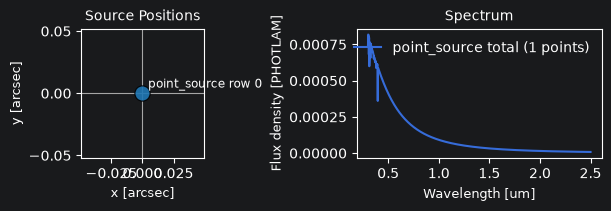

wdzshoo_wdmodel_fluxcal


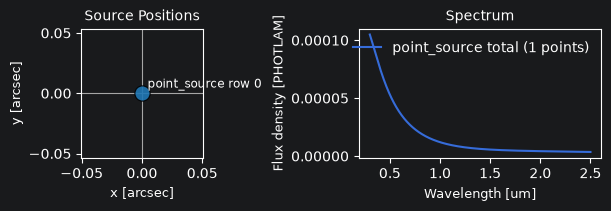

In [9]:
from synphot import SourceSpectrum
import astropy.units as u

spectra_path = Path("source_data/Carl_WD/").resolve()
spectrum_files = sorted(spectra_path.glob("*.dat"))

sources = dict()
for specfile in spectrum_files:
    basename = specfile.stem
    sp = SourceSpectrum.from_file(str(specfile), wave_unit=u.AA, flux_unit=u.mJy)
    sources[basename] = sim_tp.misc.point_source(sed=sp)
    print(basename)
    _ = PlotScene().from_source(sources[basename])
    plt.show()

### Create sources

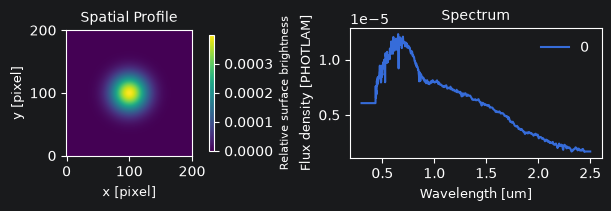

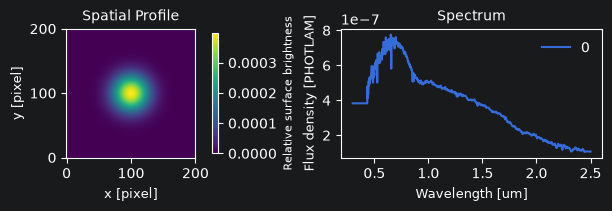

In [155]:
asteroid_spectrum = pd.read_csv('source_data/Karen_comet/asteroid32_TOA_V20.csv', comment='#')
solar_spectrum = pd.read_csv('source_data/Karen_comet/Arvesen1969_user_transcription_QC_nm.txt', comment='#', sep='\s+',
                    header=None)
sowave = solar_spectrum[0].to_numpy()*10 * u.AA
soflux = convert_flux(sowave, solar_spectrum[1].to_numpy()*(u.Watt/(u.m**2)/u.nm), "FLAM")
solarsed = empirical_spectrum(sowave, soflux)
sed = empirical_spectrum(wave=(asteroid_spectrum['wavelength_nm'].to_numpy()*u.nm).to(u.AA),
                         flux=(asteroid_spectrum['flux_erg_s_cm2_A'].to_numpy()*FLAM))

from astropy.modeling.models import Gaussian2D
y_grid, x_grid = np.mgrid[-100:100, -100:100]
model = Gaussian2D(amplitude=1., x_mean=0, y_mean=0, x_stddev=20, y_stddev=20)(x_grid, y_grid)

sources = {}
for mag in [20, 23, 25]:
    sources[f'point_ast_{mag}'] = sim_tp.misc.point_source(sed=sed, amplitude=float(mag), filter_curve='V')
    sources[f'blob_ast_{mag}'] = sim_tp.misc.source_from_array(arr=model, sed=sed, pixel_scale=0.01, amplitude=mag,
                                                               filter_curve='V')
_ = PlotScene().from_source(sources['blob_ast_20'])
_ = PlotScene().from_source(sources['blob_ast_23'])


### Simulating cal+science at one observing configuration

Set your observing parameters in cell below.

If you change any instrument related parameters for a science obejct simulation (like vis_slit, nir_slit, ao_on or diffuse_emissivity_on)
 - **<font color='red'>Make sure to simulate a complementary set of cals with the same parameters!</font>**
 - **<font color='red'>Make sure you CHANGE the output_dir so that your data doesn't get overwritten!</font>**

In [197]:
airmass = 1.1
seeing = 0.65
brightness = "dark"
vis_slit = 0.7
nir_slit = 0.7
ao_on = False
diffuse_emissivity_on = False
params = {"!SIM.spectral.spectral_bin_width": 0.00001}
# creating a sub-directory in OUTDIR for this run config, naming it based on config params
output_dir = OUTDIR / f"slit_{vis_slit}"
output_dir.mkdir(parents=True, exist_ok=True)

overwrite_cals = True  # set True to redo cals
plot = False  # Set True for plotting

args = {'airmass':airmass, 'seeing':seeing, 'brightness':brightness, 'vis_slit':vis_slit, 'nir_slit':nir_slit,
        'ao_on': ao_on, 'diffuse_emissivity_on': diffuse_emissivity_on, 'params': params}

In [170]:
# for cals
disable_effects_cals = ["atmo_transmission", "continuum_emission", "airglow_and_interline_continuum",
                        "seeing_psf", "adc_residuals"]
if overwrite_cals or len(sorted(output_dir.glob("*bias*")))!=6:
    # bias
    bias_hdul, _ = update_params_and_observe(object_name="bias", imagetype="BIAS", source=None, exptimes=0,
                                             output_dir=output_dir, disable_effects=disable_effects_cals, **args)
    # arcs
    LAMP = lamp_flat()
    arcs_hdul, _ = update_params_and_observe(object_name="arcs", imagetype="ARCS", source=LAMP,
                                             exptimes=[40, 40, 3, 3, 20, 10], output_dir=output_dir,
                                             disable_effects=disable_effects_cals, **args)
    # domeflat
    DOMEFLAT = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=8*u.ABmag, filter_curve='V', extend=60)
    domeflat_hdul, _ = update_params_and_observe(object_name="domeflat", imagetype="DOMEFLAT", source=DOMEFLAT,
                                                 exptimes=[120, 10, 3, 3, 3, 3], output_dir=output_dir,
                                                 disable_effects=disable_effects_cals, **args)
    # standard star
    STANDARD = sim_tp.misc.point_source(sed=source_templates.ab_spectrum(mag=16))
    std_hdul, _ = update_params_and_observe(object_name="standard", imagetype="SCIENCE", source=STANDARD,
                                            exptimes=300, disable_backgrounds=["sky"], output_dir=output_dir, **args)
    if plot:
        _, _ = plot_readout_overview(bias_hdul,
                                        titles=[f"bias {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = PlotScene().from_source(LAMP)
        _, _ = plot_readout_overview(arcs_hdul,
                                        titles=[f"arcs {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(domeflat_hdul,
                                        titles=[f"domeflat {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])
        _, _ = plot_readout_overview(std_hdul,
                                        titles=[f"standard {chan}" for chan in ["BLUE", "GREEN", "RED", "YJ", "H", "K"]])

Simulating bias
Max counts per channel: [1040, 1040, 1040, 2, 2, 2]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(bias): 29.2 s
Simulating arcs
Max counts per channel: [24831, 33570, 33427, 31861, 35210, 37727]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(arcs): 31.2 s
Simulating domeflat
Max counts per channel: [39957, 41818, 49470, 68608, 76701, 72501]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(domeflat): 30.9 s
Simulating standard
Max counts per channel: [1378, 1488, 1636, 616, 678, 2448]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(standard): 43.0 s


In [171]:
# Using point asteroid for these sims not blob
for exptime in [1800]:
    sky_hduls, _ = update_params_and_observe(object_name=f"sky_{exptime}", imagetype="SKY", source=None, exptimes=exptime, output_dir=output_dir, **args)

    objname = 'point_ast_20'
    hduls, _ = update_params_and_observe(object_name=f"{objname}_{exptime}", imagetype="SCIENCE", source=sources[objname], exptimes=exptime, ndit=2, output_dir=output_dir, **args)

    for i, hdul in enumerate(hduls):
        sub_hdul = subtract_hduls(hdul, sky_hduls[0])
        _ = save_zshooter_readout(sub_hdul, output_dir=output_dir, object_name=f"{objname}_{exptime}_SUB",
                                  imagetype="SCIENCE", ndit=i, cmds=None, train=None, extra_headers={"SUBTRACTED": True})

Simulating sky_1800
Max counts per channel: [1059, 5137, 15257, 97797, 496201, 277701]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(sky_1800): 48.3 s
Simulating point_ast_20_1800
Max counts per channel: [1083, 5139, 15409, 98033, 497796, 277615]
Saved readout #0/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
Max counts per channel: [1081, 5114, 15349, 97857, 496776, 276909]
Saved readout #1/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(point_ast_20_1800): 108.3 s


In [172]:
for exptime in [3600]:
    sky_hduls, _ = update_params_and_observe(object_name=f"sky_{exptime}", imagetype="SKY", source=None, exptimes=exptime, output_dir=output_dir, **args)

    objname = 'point_ast_23'
    hduls, _ = update_params_and_observe(object_name=f"{objname}_{exptime}", imagetype="SCIENCE", source=sources[objname], exptimes=exptime, ndit=2, output_dir=output_dir, **args)

    for i, hdul in enumerate(hduls):
        sub_hdul = subtract_hduls(hdul, sky_hduls[0])
        _ = save_zshooter_readout(sub_hdul, output_dir=output_dir, object_name=f"{objname}_{exptime}_SUB",
                                  imagetype="SCIENCE", ndit=i, cmds=None, train=None, extra_headers={"SUBTRACTED": True})

Simulating sky_3600
Max counts per channel: [1074, 9149, 29447, 195232, 993469, 554490]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(sky_3600): 48.2 s
Simulating point_ast_23_3600
Max counts per channel: [1074, 9170, 29410, 195306, 993575, 555765]
Saved readout #0/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
Max counts per channel: [1075, 9128, 29364, 195436, 994584, 556329]
Saved readout #1/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(point_ast_23_3600): 112.1 s


In [173]:
for exptime in [5400]:
    sky_hduls, _ = update_params_and_observe(object_name=f"sky_{exptime}", imagetype="SKY", source=None, exptimes=exptime, output_dir=output_dir, **args)

    objname = 'point_ast_25'
    hduls, _ = update_params_and_observe(object_name=f"{objname}_{exptime}", imagetype="SCIENCE", source=sources[objname], exptimes=exptime, ndit=2, output_dir=output_dir, **args)

    for i, hdul in enumerate(hduls):
        sub_hdul = subtract_hduls(hdul, sky_hduls[0])
        _ = save_zshooter_readout(sub_hdul, output_dir=output_dir, object_name=f"{objname}_{exptime}_SUB",
                                  imagetype="SCIENCE", ndit=i, cmds=None, train=None, extra_headers={"SUBTRACTED": True})

Simulating sky_5400
Max counts per channel: [1085, 13101, 43435, 293121, 1490292, 831906]
Saved readout #0/1 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(sky_5400): 48.6 s
Simulating point_ast_25_5400
Max counts per channel: [1091, 13064, 43565, 292915, 1490728, 833526]
Saved readout #0/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
Max counts per channel: [1085, 13143, 43576, 293529, 1492496, 831481]
Saved readout #1/2 in /Users/yashvi/Desktop/ZShooter/zs-scopesim/notebooks/05_Comets/slit_0.7
update_params_and_observe(point_ast_25_5400): 110.3 s


### Reducing the simulated readouts with Pyreduce

Set `REDUCED_DIR` - where outputs of reduction will be saved (simply set to `reduced/` folder inside simulation output) directory.

In [198]:
REDUCED_DIR = output_dir / f"reduced"
REDUCED_DIR.mkdir(exist_ok=True)

In [175]:
from zsdrp.ZSHOOTER import ZSHOOTER
zspy = ZSHOOTER()
files = {}
for chan in zspy.config.channels:
    stepnames = ['bias','flat','wavecal_master','science']
    file_groups = zspy.sort_files(str(output_dir), target='', night='', channel=chan, steps=stepnames)
    _, fls = file_groups[0]
    files[chan] = {name: fls[name] for name in stepnames}
# files[chan]

100%|██████████| 114/114 [00:00<00:00, 1511.45it/s]


In [176]:
import zsdrp.pipe
from scopesim.source.source_templates import ab_spectrum
from synphot.units import convert_flux

results = zsdrp.pipe.run_reduction(files, channels=None, output_dir=REDUCED_DIR, disable_steps=['mask'], print_params=False, disable_all_plots=True, reuse_cals=False)

reference = ab_spectrum(mag=16)
reference_wave = reference.waveset
reference_flux = convert_flux(reference_wave, reference(reference_wave), "FLAM")

final_spectra = zsdrp.pipe.run_flux_calibration_and_stitch(results, reference_wave=reference_wave, reference_flux=reference_flux, plot=False, output_dir=REDUCED_DIR)

Running reduction for channel BLUE...


Trace: 100%|██████████| 34/34 [00:03<00:00, 10.65it/s]


simple_wavesol: 728/728 lines, channel +0.010 -0.025 x/nx px, rms 0.286 px
Running reduction for channel GREEN...


Trace: 100%|██████████| 30/30 [00:05<00:00,  5.74it/s]


simple_wavesol: 706/710 lines, channel -0.014 -0.017 x/nx px, rms 0.110 px
Running reduction for channel RED...


...

simple_wavesol: 165/170 lines, channel -0.003 -0.001 x/nx px, rms 0.024 px
Running reduction for channel H...


Trace: 100%|██████████| 11/11 [00:01<00:00,  9.09it/s]


simple_wavesol: 100/100 lines, channel +0.000 -0.000 x/nx px, rms 0.017 px
Running reduction for channel K...


Trace: 100%|██████████| 8/8 [00:00<00:00, 10.85it/s]


simple_wavesol: 56/56 lines, channel +0.000 -0.006 x/nx px, rms 0.045 px


In [177]:
del results
del final_spectra

point_ast_20_1800_SUB: median SNR = 14.09
point_ast_20_1800_SUB: binned 10 median SNR = 57.45, min SNR = 8.63
point_ast_20_1800_SUB: binned 20 median SNR = 80.35, min SNR = 17.05
point_ast_20_1800_SUB: binned 40 median SNR = 111.28, min SNR = 32.41
point_ast_20_1800_SUB: binned 200 median SNR = 242.03, min SNR = 98.45
point_ast_23_3600_SUB: median SNR = 1.26
point_ast_23_3600_SUB: binned 10 median SNR = 7.15, min SNR = -2.43
point_ast_23_3600_SUB: binned 20 median SNR = 9.99, min SNR = 0.08
point_ast_23_3600_SUB: binned 40 median SNR = 13.84, min SNR = 0.66
point_ast_23_3600_SUB: binned 200 median SNR = 30.50, min SNR = 5.67
point_ast_25_5400_SUB: median SNR = 0.05
point_ast_25_5400_SUB: binned 10 median SNR = 0.48, min SNR = -13.25
point_ast_25_5400_SUB: binned 20 median SNR = 0.75, min SNR = -12.30
point_ast_25_5400_SUB: binned 40 median SNR = 1.14, min SNR = -11.18
point_ast_25_5400_SUB: binned 200 median SNR = 3.01, min SNR = -6.71


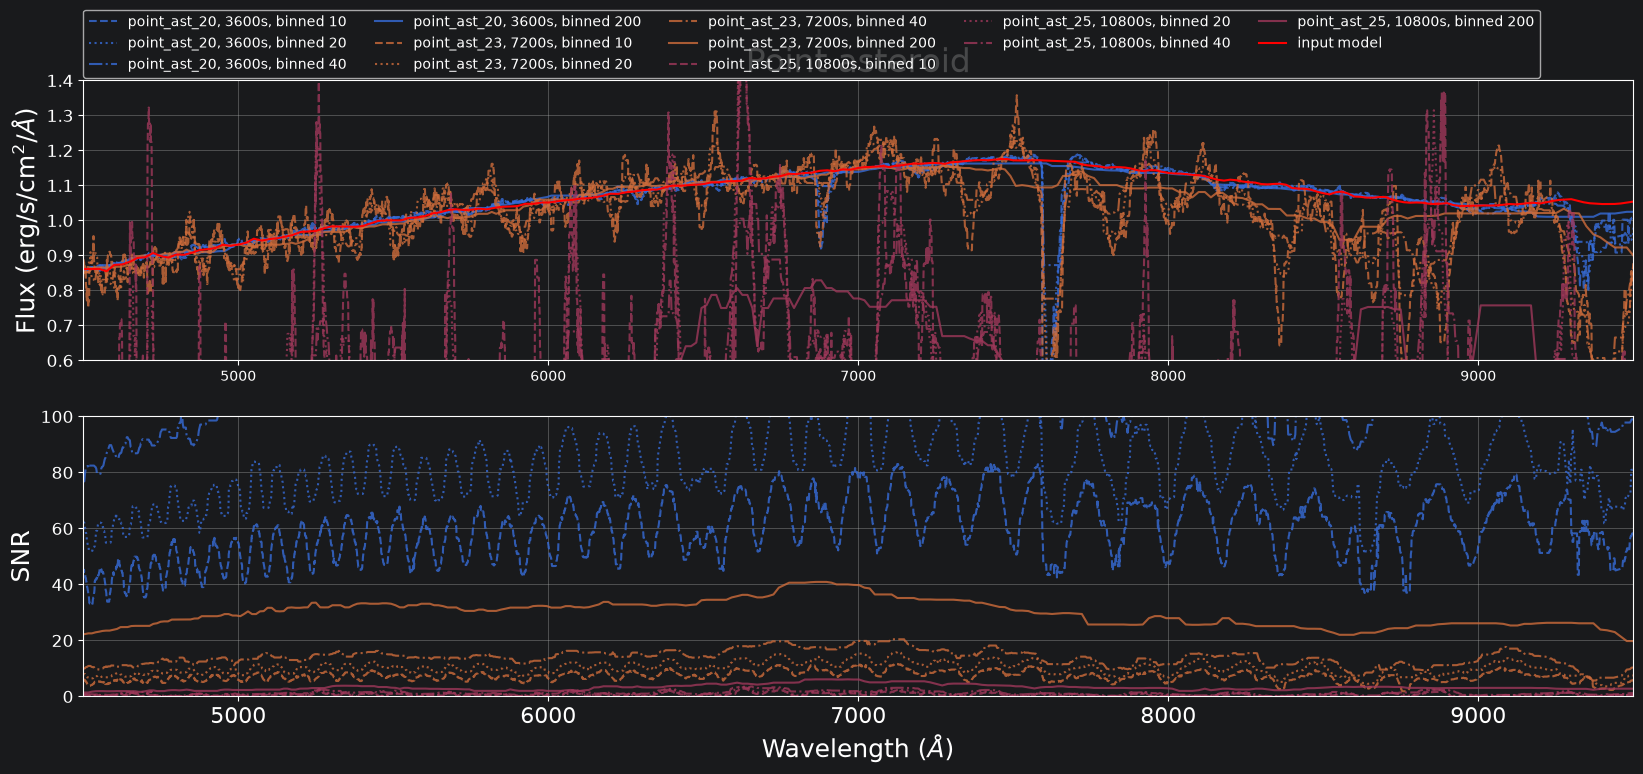

In [207]:
REDUCED_DIR = OUTDIR / f"slit_0.7/reduced"
REDUCED_DIR.mkdir(exist_ok=True)

from scipy.ndimage import median_filter
import pandas as pd

fig, ax = plt.subplots(2,1, figsize=(20,8))
ax[0].grid(True)
ax[1].grid(True)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='x', labelsize=16)
ax[0].set_ylabel('Flux (erg/s/cm$^2/\AA$)', fontsize=18)
ax[1].set_ylabel('SNR', fontsize=18)
ax[1].set_xlabel('Wavelength ($\AA$)', fontsize=18)

stitched = sorted(REDUCED_DIR.glob('*stitched.txt'))

obj = list(sources.keys())[0]
for i, (mag, exp) in enumerate(zip([20, 23, 25], [1800, 3600, 5400])):
# for i, (mag, exp) in enumerate(zip([20], [1800])):
    objname = f"point_ast_{mag}_{exp}_SUB"
    flname = sorted(REDUCED_DIR.glob(f'*{objname.upper()}_stitched.txt'))[0]
    with open(flname, 'r', encoding='utf-8') as f:
        tbl = pd.read_csv(f, sep='\t', comment='# ', engine='python')
        wave = tbl['wavelength'].to_numpy()
        spec = tbl['flux'].to_numpy()
        sig = tbl['eflux'].to_numpy()
        snr = spec/sig
        good = np.isfinite(snr)
        print(f"{objname}: median SNR = {np.median(snr[good]):.2f}")

        # ax[0].plot(wave, spec, alpha=0.2, color=f"C{i}")
        # ax[0].plot(wave, median_filter(spec, 51), color=f"C{i}", label=f"point_ast_{mag}, {2*exp}s")
        # ax[1].plot(wave, snr, alpha=0.2, color=f"C{i}")
        # ax[1].plot(wave, median_filter(snr , 51), color=f"C{i}")

        solar = sim_tp.misc.point_source(sed=solarsed, amplitude=mag, filter_curve='V')
        tbl['reflectance'] = spec / convert_flux(wave, solar.spectra[0](wave), "FLAM").value

        for binsize, ls in zip([10, 20, 40, 200], ['--', 'dotted', '-.', '-']):
            tbl[f'bins_{binsize}'] = np.arange(len(tbl)) // binsize
            binned = []
            for _, group in tbl.groupby(by=f'bins_{binsize}'):
                binned.append([np.mean(group['wavelength']),
                               np.mean(group['flux']),
                               np.sqrt(np.sum(group['eflux']**2))/len(group)])
            bintbl = pd.DataFrame(binned, columns=['wavelength', 'flux', 'eflux'])
            binwave = bintbl['wavelength'].to_numpy()

            soflux = convert_flux(binwave, solar.spectra[0](binwave), "FLAM").value
            binref = bintbl['flux'].to_numpy() / soflux
            bintbl['reflectance'] = binref

            binsnr = bintbl['flux']/bintbl['eflux']
            sel = (binwave > 4500) & (binwave < 9500)
            print(f"{objname}: binned {binsize} median SNR = {np.nanmedian(binsnr[sel]):.2f}, min SNR = {np.nanmin(binsnr[sel]):.2f}")
            ax[0].plot(bintbl['wavelength'], median_filter(binref, 31), alpha=0.8, color=f"C{i}", ls=ls,
                       label=f"point_ast_{mag}, {2*exp}s, binned {binsize}")
            ax[1].plot(bintbl['wavelength'], median_filter(binsnr, 31), alpha=0.8, color=f"C{i}", ls=ls)

            bintbl.to_csv(str(flname).replace('stitched', f'stitched_binned_{binsize}'), sep='\t', index=False)
        tbl.to_csv(str(flname), sep='\t', index=False)

ax[0].plot(asteroid_spectrum['wavelength_nm']*10, asteroid_spectrum['reflectance_interp'], color='red', label='input model')
ax[0].set_title('Point asteroid', fontsize=24)
ax[0].set_xlim(4500, 9500)
ax[1].set_xlim(4500, 9500)
ax[0].set_ylim(0.6, 1.4)
ax[1].set_ylim(0, 100)
ax[0].legend(ncol=5, loc=(0,1.01))
plt.show()

point_ast_20_1800_SUB: median SNR = 14.18
point_ast_20_1800_SUB: binned 200 median SNR = 253.66, min SNR = 81.51
point_ast_20_1800_SUB: binned 400 median SNR = 350.23, min SNR = 148.27
point_ast_23_1800_SUB: median SNR = 0.61
point_ast_23_1800_SUB: binned 200 median SNR = 21.20, min SNR = 0.45
point_ast_23_1800_SUB: binned 400 median SNR = 28.62, min SNR = 0.71
point_ast_25_3600_SUB: median SNR = 0.02
point_ast_25_3600_SUB: binned 200 median SNR = 1.50, min SNR = -5.68
point_ast_25_3600_SUB: binned 400 median SNR = 2.37, min SNR = -5.03


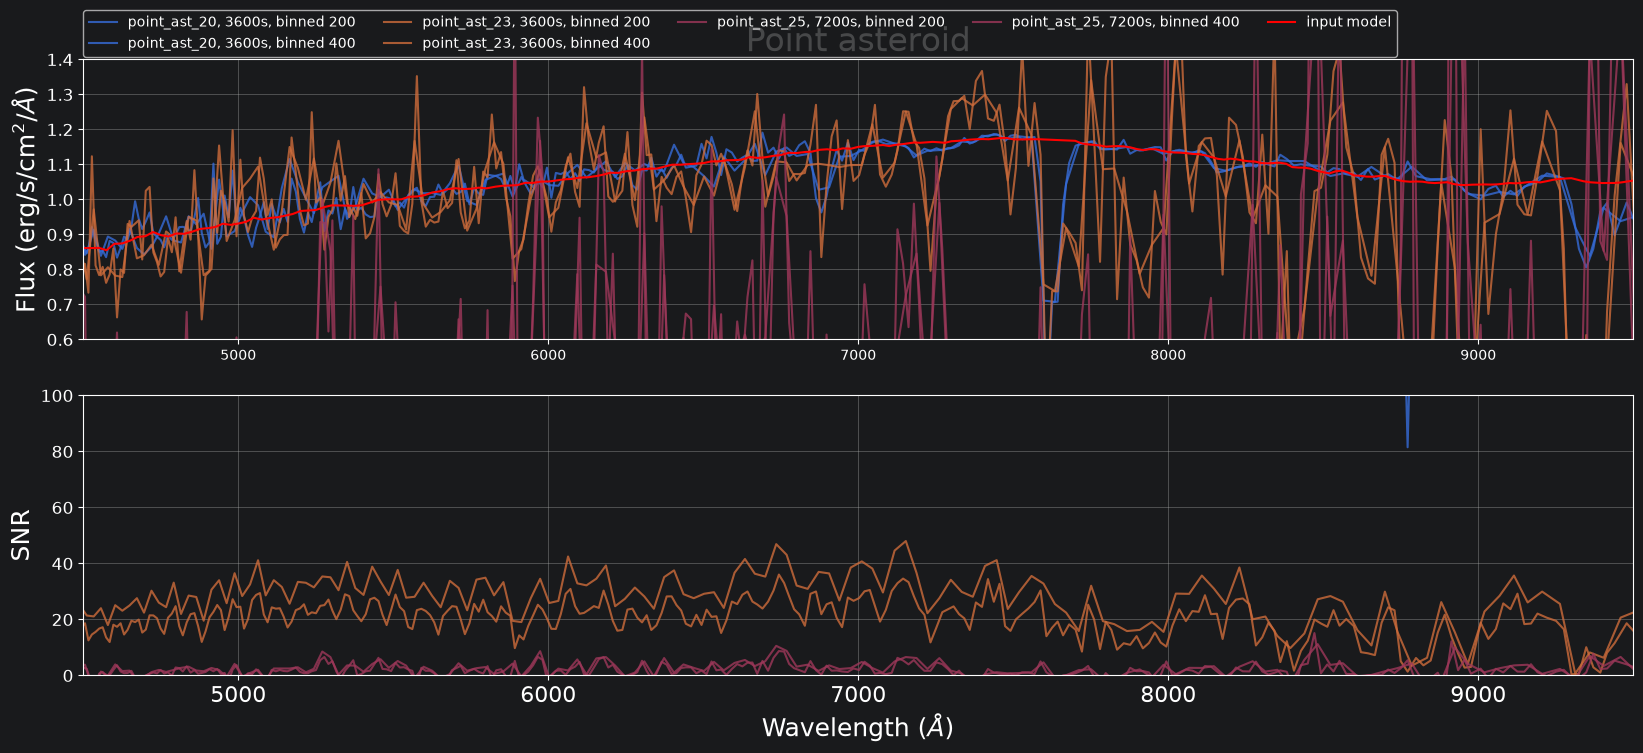

In [212]:
REDUCED_DIR = OUTDIR / f"slit_1.25/reduced"
REDUCED_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(2,1, figsize=(20,8))
ax[0].grid(True)
ax[1].grid(True)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='x', labelsize=16)
ax[0].set_ylabel('Flux (erg/s/cm$^2/\AA$)', fontsize=18)
ax[1].set_ylabel('SNR', fontsize=18)
ax[1].set_xlabel('Wavelength ($\AA$)', fontsize=18)

stitched = sorted(REDUCED_DIR.glob('*stitched.txt'))

obj = list(sources.keys())[0]
for i, (mag, exp) in enumerate(zip([20, 23, 25], [1800, 1800, 3600])):
# for i, (mag, exp) in enumerate(zip([20], [1800])):
    objname = f"point_ast_{mag}_{exp}_SUB"
    flname = sorted(REDUCED_DIR.glob(f'*{objname.upper()}_stitched.txt'))[0]
    with open(flname, 'r', encoding='utf-8') as f:
        tbl = pd.read_csv(f, sep='\t', comment='# ', engine='python')
        wave = tbl['wavelength'].to_numpy()
        spec = tbl['flux'].to_numpy()
        sig = tbl['eflux'].to_numpy()
        snr = spec/sig
        good = np.isfinite(snr)
        print(f"{objname}: median SNR = {np.median(snr[good]):.2f}")

        # ax[0].plot(wave, spec, alpha=0.2, color=f"C{i}")
        # ax[0].plot(wave, median_filter(spec, 51), color=f"C{i}", label=f"point_ast_{mag}, {2*exp}s")
        # ax[1].plot(wave, snr, alpha=0.2, color=f"C{i}")
        # ax[1].plot(wave, median_filter(snr , 51), color=f"C{i}")

        solar = sim_tp.misc.point_source(sed=solarsed, amplitude=mag, filter_curve='V')
        tbl['reflectance'] = spec / convert_flux(wave, solar.spectra[0](wave), "FLAM").value

        for binsize in [200, 400]:
            tbl[f'bins_{binsize}'] = np.arange(len(tbl)) // binsize
            binned = []
            for _, group in tbl.groupby(by=f'bins_{binsize}'):
                binned.append([np.mean(group['wavelength']),
                               np.mean(group['flux']),
                               np.sqrt(np.sum(group['eflux']**2))/len(group)])
            bintbl = pd.DataFrame(binned, columns=['wavelength', 'flux', 'eflux'])
            binwave = bintbl['wavelength'].to_numpy()

            soflux = convert_flux(binwave, solar.spectra[0](binwave), "FLAM").value
            binref = bintbl['flux'].to_numpy() / soflux
            bintbl['reflectance'] = binref

            binsnr = bintbl['flux']/bintbl['eflux']
            sel = (binwave > 4500) & (binwave < 9500)
            print(f"{objname}: binned {binsize} median SNR = {np.nanmedian(binsnr[sel]):.2f}, min SNR = {np.nanmin(binsnr[sel]):.2f}")
            ax[0].plot(bintbl['wavelength'], median_filter(binref, 1), alpha=0.8, color=f"C{i}",
                       label=f"point_ast_{mag}, {2*exp}s, binned {binsize}")
            ax[1].plot(bintbl['wavelength'], median_filter(binsnr, 1), alpha=0.8, color=f"C{i}")

            bintbl.to_csv(str(flname).replace('stitched', f'stitched_binned_{binsize}'), sep='\t', index=False)
        tbl.to_csv(str(flname), sep='\t', index=False)

ax[0].plot(asteroid_spectrum['wavelength_nm']*10, asteroid_spectrum['reflectance_interp'], color='red', label='input model')
ax[0].set_title('Point asteroid', fontsize=24)
ax[0].set_xlim(4500, 9500)
ax[1].set_xlim(4500, 9500)
ax[0].set_ylim(0.6, 1.4)
ax[1].set_ylim(0, 100)
ax[0].legend(ncol=5, loc=(0,1.01))
plt.show()